In [4]:
from pathlib import Path
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from torch import amp

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

ROOT = Path(".")
DATA = ROOT / "data"
TRAIN_DIR = DATA / "train"
TEST_DIR  = DATA / "test"
OUT       = ROOT / "outputs"; OUT.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_EXTS   = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
IMG_SIZE   = 128
BATCH      = 64
EPOCHS     = 25
NUM_WORKERS= 0


Scanining Scan folders and building label map

In [31]:
def is_genuine_dir(name: str) -> bool:
    """Return True if a folder name corresponds to genuine signatures (i.e., does not end with '_forg')."""
    return not name.lower().endswith("_forg")

def list_genuine(root: Path):
    """
    Collect image paths and person IDs from genuine-only folders.

    Parameters
    ----------
    root : Path
        Root directory that contains person subfolders.

    Returns
    -------
    paths : list[Path]
        All image paths from genuine folders.
    person_ids : list[str]
        Person IDs (folder names) aligned with `paths`.
    """
    paths, person_ids = [], []
    for d in sorted([x for x in root.iterdir() if x.is_dir() and is_genuine_dir(x.name)]):
        pid = d.name
        for f in d.rglob("*"):
            if f.suffix.lower() in IMG_EXTS:
                paths.append(f)
                person_ids.append(pid)
    return paths, person_ids

tr_paths, tr_pids = list_genuine(TRAIN_DIR)
te_paths, te_pids = list_genuine(TEST_DIR)

all_pids = sorted(set(tr_pids))
pid2idx  = {p:i for i,p in enumerate(all_pids)}
idx2pid  = {i:p for p,i in pid2idx.items()}

y_tr = [pid2idx[p] for p in tr_pids]
X_te = [p for p, pid in zip(te_paths, te_pids) if pid in pid2idx]
y_te = [pid2idx[pid] for pid in te_pids if pid in pid2idx]

idx_all = np.arange(len(tr_paths))
tr_idx, va_idx = train_test_split(idx_all, test_size=0.15, random_state=SEED, stratify=y_tr)

Xtr = [tr_paths[i] for i in tr_idx]; ytr = [y_tr[i] for i in tr_idx]
Xva = [tr_paths[i] for i in va_idx]; yva = [y_tr[i] for i in va_idx]

num_classes = len(all_pids)


Removing unreadable files

In [32]:
def keep_readable(paths, labels):
    """
    Filter out images that cannot be opened by PIL.

    Parameters
    ----------
    paths : list[Path]
        Image paths to validate.
    labels : list[int]
        Labels aligned with `paths`.

    Returns
    -------
    kept_paths : list[Path]
        Paths that PIL could open.
    kept_labels : list[int]
        Aligned labels for the kept paths.
    """
    kept_p, kept_l = [], []
    for p, y in zip(paths, labels):
        try:
            _ = Image.open(p).convert("L")
            kept_p.append(p); kept_l.append(y)
        except Exception:
            pass
    return kept_p, kept_l

Xtr, ytr = keep_readable(Xtr, ytr)
Xva, yva = keep_readable(Xva, yva)
X_te, y_te = keep_readable(X_te, y_te)


Dataset and DataLoaders

In [33]:
class SignIDDataset(Dataset):
    """
    PyTorch Dataset for multiclass person identification on grayscale signatures.

    Parameters
    ----------
    paths : list[Path]
        Image file paths.
    labels : list[int]
        Encoded person-ID labels.
    image_size : int
        Target square image size.
    augment : bool
        If True, applies mild geometric augmentation.

    Returns
    -------
    __getitem__(i) -> (Tensor, Tensor)
        A pair of (image tensor [1,H,W] in [0,1], class index).
    """
    def __init__(self, paths, labels, image_size=128, augment=False):
        tfs = []
        if augment:
            tfs += [
                transforms.RandomRotation(3),
                transforms.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.98, 1.02)),
            ]
        tfs += [transforms.Resize((image_size, image_size)), transforms.ToTensor()]
        self.tf = transforms.Compose([transforms.Grayscale(1), *tfs])
        self.paths = list(paths)
        self.labels = list(labels)
        self.image_size = image_size

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        p = self.paths[i]
        y = torch.tensor(self.labels[i], dtype=torch.long)
        try:
            x = Image.open(p).convert("L")
            x = self.tf(x)
            return x, y
        except Exception:
            x = torch.zeros(1, self.image_size, self.image_size, dtype=torch.float32)
            return x, y

ds_tr = SignIDDataset(Xtr, ytr, IMG_SIZE, augment=True)
ds_va = SignIDDataset(Xva, yva, IMG_SIZE, augment=False)
ds_te = SignIDDataset(X_te, y_te, IMG_SIZE, augment=False)

dl_tr = DataLoader(ds_tr, batch_size=BATCH, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
dl_va = DataLoader(ds_va, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
dl_te = DataLoader(ds_te, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


Model and optimization

In [34]:
class SmallIDCNN(nn.Module):
    """
    Compact CNN for person-ID classification on grayscale signatures.

    Architecture
    ------------
    Three convolutional blocks with ReLU and MaxPool, followed by two fully-connected layers.
    The final layer outputs logits with dimension equal to the number of classes.

    Parameters
    ----------
    image_size : int
        Side length of the square input image.
    num_classes : int
        Number of person-ID classes to predict.
    """
    def __init__(self, image_size=128, num_classes=10):
        super().__init__()
        self.c1 = nn.Conv2d(1,  32, 3, padding=1)
        self.c2 = nn.Conv2d(32, 64, 3, padding=1)
        self.c3 = nn.Conv2d(64,128, 3, padding=1)
        self.p  = nn.MaxPool2d(2)
        self.drop= nn.Dropout(0.4)
        self.flat = 128 * (image_size // 8) * (image_size // 8)
        self.fc1 = nn.Linear(self.flat, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.p(F.relu(self.c1(x)))
        x = self.p(F.relu(self.c2(x)))
        x = self.p(F.relu(self.c3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)

model = SmallIDCNN(IMG_SIZE, num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


C:\Users\moizs\AppData\Local\Temp\ipykernel_33776\3670696573.py:40: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


Epoch runner and trainer

In [35]:
def run_epoch(model, dataloader, optimizer, criterion, device, train=True):
    """
    Execute one epoch over a dataloader.

    Parameters
    ----------
    model : nn.Module
        Model to train or evaluate.
    dataloader : DataLoader
        Iterable of (image, label) batches.
    optimizer : torch.optim.Optimizer
        Optimizer used when train=True.
    criterion : nn.Module
        Loss function (cross entropy).
    device : torch.device
        CUDA or CPU device.
    train : bool
        If True, updates weights; otherwise eval only.

    Returns
    -------
    mean_loss : float
        Average loss over all batches.
    acc : float
        Overall accuracy.
    prec : float
        Macro precision across classes.
    rec : float
        Macro recall across classes.
    f1 : float
        Macro F1 across classes.
    """
    model.train() if train else model.eval()
    losses, preds, gts = [], [], []
    use_amp = (device.type == "cuda")
    with torch.set_grad_enabled(train):
        for xb, yb in dataloader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            if train:
                optimizer.zero_grad(set_to_none=True)
            with amp.autocast('cuda', enabled=use_amp):
                logits = model(xb)
                loss = criterion(logits, yb)
            if train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            losses.append(loss.item())
            preds.extend(torch.argmax(logits, dim=1).detach().cpu().numpy().tolist())
            gts.extend(yb.detach().cpu().numpy().tolist())
    acc = accuracy_score(gts, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(gts, preds, average="macro", zero_division=0)
    return float(np.mean(losses)), acc, prec, rec, f1


def train_model(model, dl_tr, dl_va, optimizer, criterion, device, epochs, out_dir):
    """
    Train a multiclass CNN with mixed precision and save the checkpoint with best validation macro-F1.

    Parameters
    ----------
    model : nn.Module
        The CNN to train.
    dl_tr : DataLoader
        Training dataloader.
    dl_va : DataLoader
        Validation dataloader.
    optimizer : torch.optim.Optimizer
        Optimizer instance.
    criterion : nn.Module
        Loss function.
    device : torch.device
        CUDA or CPU device.
    epochs : int
        Number of epochs.
    out_dir : Path
        Output directory to save plots and weights.

    Returns
    -------
    history : dict[str, list[float]]
        Recorded training and validation metrics per epoch.
    best_path : Path
        Path to the best checkpoint saved during training.
    """
    history = {"tr_loss": [], "va_loss": [], "tr_acc": [], "va_acc": [], "va_f1": []}
    best_f1, best_path = -1.0, out_dir / "best_cnn_id.pth"

    for ep in range(1, epochs + 1):
        tl, ta, _, _, _ = run_epoch(model, dl_tr, optimizer, criterion, device, train=True)
        vl, va, vp, vr, vf = run_epoch(model, dl_va, optimizer, criterion, device, train=False)

        history["tr_loss"].append(tl); history["va_loss"].append(vl)
        history["tr_acc"].append(ta);  history["va_acc"].append(va); history["va_f1"].append(vf)

        print(f"Epoch {ep:02d} | loss {tl:.4f}/{vl:.4f} | acc {ta:.3f}/{va:.3f} | macroF1 {vf:.3f}")
        if vf > best_f1:
            best_f1 = vf
            torch.save(model.state_dict(), best_path)

    return history, best_path


Train and plot

Epoch 01 | loss 4.1789/4.1669 | acc 0.029/0.022 | macroF1 0.001
Epoch 02 | loss 4.1496/4.1635 | acc 0.025/0.030 | macroF1 0.007
Epoch 03 | loss 4.1350/4.1581 | acc 0.029/0.052 | macroF1 0.024
Epoch 04 | loss 4.1031/4.0938 | acc 0.048/0.067 | macroF1 0.009
Epoch 05 | loss 3.9437/3.8209 | acc 0.061/0.112 | macroF1 0.044
Epoch 06 | loss 3.5800/3.1558 | acc 0.165/0.231 | macroF1 0.131
Epoch 07 | loss 2.8222/2.1838 | acc 0.291/0.440 | macroF1 0.338
Epoch 08 | loss 2.1619/1.5927 | acc 0.410/0.657 | macroF1 0.583
Epoch 09 | loss 1.5771/0.9587 | acc 0.541/0.731 | macroF1 0.675
Epoch 10 | loss 1.2250/0.6841 | acc 0.648/0.866 | macroF1 0.851
Epoch 11 | loss 0.9471/0.5586 | acc 0.724/0.873 | macroF1 0.861
Epoch 12 | loss 0.8122/0.4785 | acc 0.764/0.881 | macroF1 0.869
Epoch 13 | loss 0.6754/0.4828 | acc 0.778/0.888 | macroF1 0.881
Epoch 14 | loss 0.6445/0.4217 | acc 0.792/0.873 | macroF1 0.862
Epoch 15 | loss 0.5524/0.4019 | acc 0.831/0.888 | macroF1 0.880
Epoch 16 | loss 0.5100/0.4128 | acc 0.83

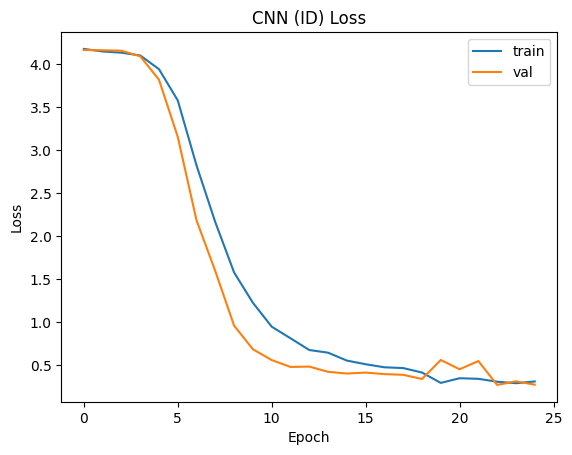

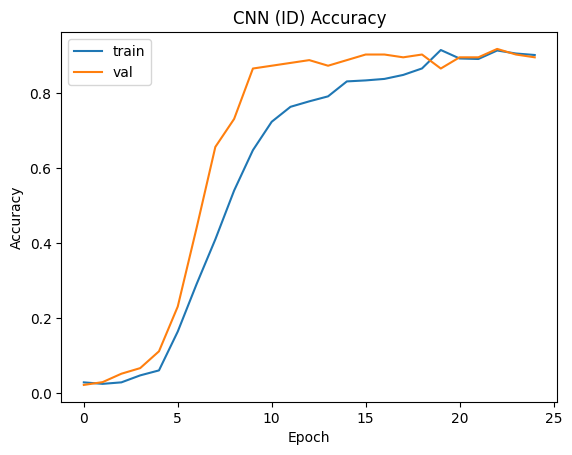

In [36]:
history, best_path = train_model(
    model=model,
    dl_tr=dl_tr,
    dl_va=dl_va,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=EPOCHS,
    out_dir=OUT
)

plt.figure()
plt.plot(history["tr_loss"], label="train")
plt.plot(history["va_loss"], label="val")
plt.legend(); plt.title("CNN (ID) Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.savefig(OUT / "cnn_id_loss.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(history["tr_acc"], label="train")
plt.plot(history["va_acc"], label="val")
plt.legend(); plt.title("CNN (ID) Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.savefig(OUT / "cnn_id_acc.png", dpi=150, bbox_inches="tight")
plt.show()


In [39]:
report_path = OUT / "cnn_classification_report.txt"
with open(report_path, "w") as f:
    f.write(report)
print(f"Saved classification report → {report_path}")

Saved classification report → outputs\cnn_classification_report.txt


Test evaluation and confusion matrix

C:\Users\moizs\AppData\Local\Temp\ipykernel_33776\3733111606.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=de

              precision    recall  f1-score   support

          20     0.0000    0.0000    0.0000         0
          34     0.0000    0.0000    0.0000         0
          36     0.0000    0.0000    0.0000         0
          43     1.0000    1.0000    1.0000        12
          44     0.9231    1.0000    0.9600        12
          45     1.0000    1.0000    1.0000        12
          46     1.0000    1.0000    1.0000        12
          47     1.0000    1.0000    1.0000        12
          48     1.0000    1.0000    1.0000        12
          49     0.9167    0.9167    0.9167        12
          50     1.0000    1.0000    1.0000        12
          51     1.0000    1.0000    1.0000        12
          52     1.0000    1.0000    1.0000        12
          53     1.0000    1.0000    1.0000        12
          54     1.0000    1.0000    1.0000        12
          55     1.0000    1.0000    1.0000        12
          56     1.0000    1.0000    1.0000        12
          57     1.0000    

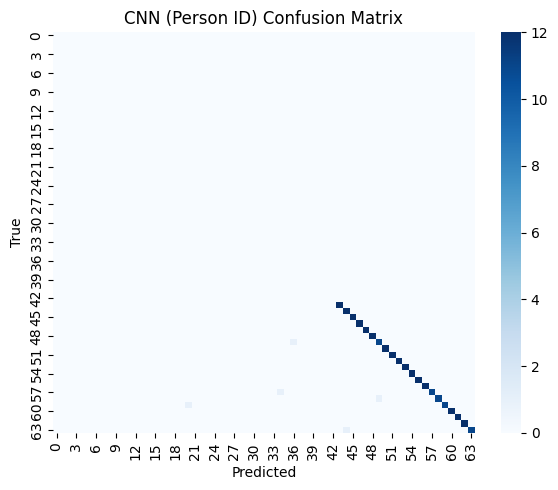

In [40]:
def evaluate_on_test(model, dl, device, num_classes):
    """
    Evaluate a trained model on the test set.

    Parameters
    ----------
    model : nn.Module
        Trained CNN with loaded weights.
    dl : DataLoader
        Test dataloader.
    device : torch.device
        CUDA or CPU device.
    num_classes : int
        Number of classes for the confusion matrix.

    Returns
    -------
    report : str
        Text classification report with macro metrics.
    cm : np.ndarray
        Confusion matrix array of shape [C, C].
    preds : list[int]
        Predicted class indices.
    gts : list[int]
        Ground-truth class indices.
    """
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(device)
            logits = model(xb)
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy().tolist())
            gts.extend(yb.numpy().tolist())
    rep = classification_report(gts, preds, digits=4)
    cm  = confusion_matrix(gts, preds, labels=list(range(num_classes)))
    return rep, cm, preds, gts

model.load_state_dict(torch.load(best_path, map_location=device))
report, cm, preds, gts = evaluate_on_test(model, dl_te, device, num_classes)

print(report)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("CNN (Person ID) Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.savefig(OUT / "cnn_id_confusion.png", dpi=150)
plt.show()


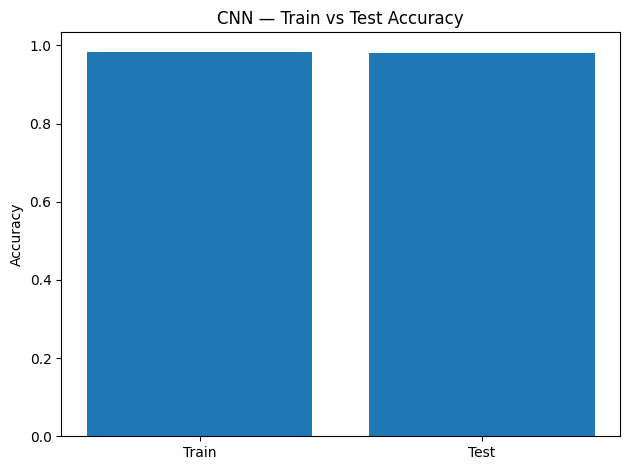

Train accuracy: 0.984
Test  accuracy: 0.980


In [6]:


def is_genuine_dir(name: str) -> bool:
    """Return True if a folder name corresponds to genuine signatures (not ending with '_forg')."""
    return not name.lower().endswith("_forg")

def list_genuine(root: Path):
    """
    Collect image paths and person IDs from genuine-only folders.

    Parameters
    ----------
    root : Path
        Root directory of a split (train/test).

    Returns
    -------
    paths : list[Path]
        Image paths from genuine folders.
    pids : list[str]
        Person IDs (folder names) aligned with paths.
    """
    paths, pids = [], []
    for d in sorted([x for x in root.iterdir() if x.is_dir() and is_genuine_dir(x.name)]):
        pid = d.name
        for f in d.rglob("*"):
            if f.suffix.lower() in IMG_EXTS:
                paths.append(f); pids.append(pid)
    return paths, pids

def keep_readable(paths, labels):
    """
    Filter out unreadable images.

    Parameters
    ----------
    paths : list[Path]
        Image paths.
    labels : list[int]
        Labels aligned with paths.

    Returns
    -------
    kp : list[Path]
        Readable paths only.
    kl : list[int]
        Labels aligned with kp.
    """
    kp, kl = [], []
    for p, y in zip(paths, labels):
        try:
            _ = Image.open(p).convert("L")
            kp.append(p); kl.append(y)
        except Exception:
            pass
    return kp, kl

class SignIDDataset(Dataset):
    """
    Dataset for person identification from grayscale signature images.

    Parameters
    ----------
    paths : list[Path]
        Image paths.
    labels : list[int]
        Encoded person-ID labels.
    image_size : int
        Target square size for resizing.

    Returns
    -------
    __getitem__(i) -> (Tensor, Tensor)
        Image tensor [1,H,W] in [0,1] and class index.
    """
    def __init__(self, paths, labels, image_size=128):
        self.tf = transforms.Compose([
            transforms.Grayscale(1),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor()
        ])
        self.paths = list(paths)
        self.labels = list(labels)

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        x = Image.open(self.paths[i]).convert("L")
        x = self.tf(x)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

class SmallIDCNN(nn.Module):
    """
    Compact CNN used during training (must match checkpoint keys).

    Architecture
    ------------
    Conv(1→32)-ReLU-MaxPool → Conv(32→64)-ReLU-MaxPool → Conv(64→128)-ReLU-MaxPool → FC(256) → FC(num_classes).

    Parameters
    ----------
    image_size : int
        Square input side length.
    num_classes : int
        Number of classes to predict.
    """
    def __init__(self, image_size=128, num_classes=10):
        super().__init__()
        self.c1 = nn.Conv2d(1,  32, 3, padding=1)
        self.c2 = nn.Conv2d(32, 64, 3, padding=1)
        self.c3 = nn.Conv2d(64,128, 3, padding=1)
        self.p  = nn.MaxPool2d(2)
        self.drop= nn.Dropout(0.4)
        self.flat = 128 * (image_size // 8) * (image_size // 8)
        self.fc1 = nn.Linear(self.flat, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.p(F.relu(self.c1(x)))
        x = self.p(F.relu(self.c2(x)))
        x = self.p(F.relu(self.c3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)

# Build label mapping from TRAIN (closed-set)
tr_paths, tr_pids = list_genuine(TRAIN_DIR)
all_pids = sorted(set(tr_pids))
pid2idx  = {p:i for i,p in enumerate(all_pids)}

y_tr = [pid2idx[p] for p in tr_pids]
tr_paths, y_tr = keep_readable(tr_paths, y_tr)

# Filter TEST to seen IDs and keep readable
te_paths, te_pids = list_genuine(TEST_DIR)
X_te = [p for p, pid in zip(te_paths, te_pids) if pid in pid2idx]
y_te = [pid2idx[pid] for pid in te_pids if pid in pid2idx]
X_te, y_te = keep_readable(X_te, y_te)

# DataLoaders
dl_tr = DataLoader(SignIDDataset(tr_paths, y_tr, IMG_SIZE), batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS)
dl_te = DataLoader(SignIDDataset(X_te, y_te, IMG_SIZE),   batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS)

# Infer num_classes from label map and load checkpoint into matching architecture
num_classes = len(all_pids)
model = SmallIDCNN(IMG_SIZE, num_classes).to(device)
state = torch.load(OUT / "best_cnn_id.pth", map_location=device, weights_only=True)
model.load_state_dict(state, strict=True)
model.eval()

# Compute accuracies
def dataloader_accuracy(m, dl, dev):
    """Return accuracy over a dataloader by argmax over logits."""
    m.eval()
    preds, gts = [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(dev)
            logits = m(xb)
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            gts.extend(yb.numpy())
    return accuracy_score(gts, preds)

train_acc = dataloader_accuracy(model, dl_tr, device)
test_acc  = dataloader_accuracy(model, dl_te, device)

plt.figure()
plt.bar(["Train", "Test"], [train_acc, test_acc])
plt.ylabel("Accuracy")
plt.title("CNN — Train vs Test Accuracy")
plt.tight_layout()
plt.savefig(OUT / "cnn_train_test_accuracy.png", dpi=150)
plt.show()

print(f"Train accuracy: {train_acc:.3f}")
print(f"Test  accuracy: {test_acc:.3f}")


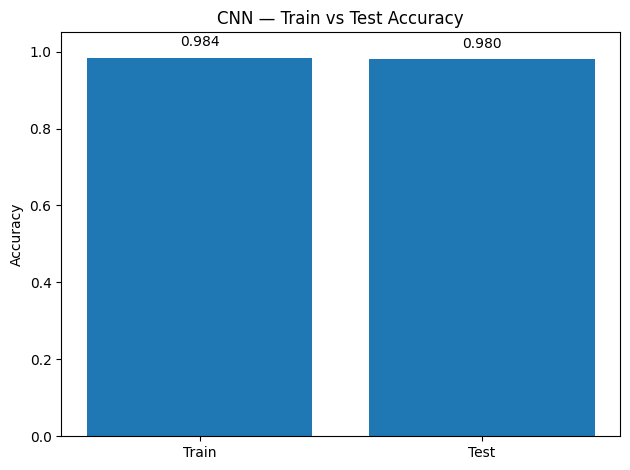

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

vals = [train_acc, test_acc]
labels = ["Train", "Test"]

fig, ax = plt.subplots()
bars = ax.bar(labels, vals)
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("CNN — Train vs Test Accuracy")

for b, v in zip(bars, vals):
    ax.annotate(f"{v:.3f}", xy=(b.get_x()+b.get_width()/2, v),
                xytext=(0, 6), textcoords="offset points",
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("outputs/cnn_train_test_accuracy.png", dpi=150)
plt.show()
